### Methodology

Physiological sleep signals—including EEG, EOG, and EMG—were analyzed at the epoch level (30-second intervals) to characterize temporal dynamics and inter-signal interactions. To account for inter-individual variability and differing signal amplitudes, EMG data were normalized using a rolling-window z-score, and all signals were standardized on a per-subject basis. Based on population-level sleep fragmentation metrics, a single subject exhibiting the highest average number of stage transitions was selected for detailed temporal analysis, representing an extreme fragmentation phenotype. Lagged versions of each signal were constructed to capture short- to medium-term temporal dependencies, enabling the application of a multivariate Vector Autoregression (VAR) model to jointly model the dynamic interactions among EEG, EOG, and EMG features.

### Vector Autoregression

**Lag Selection and Temporal Scope**

Each epoch represents 30 seconds. The model includes lags:

$$p \in {1,2,4}$$

corresponding to:

- 30 seconds,
- 1 minute,
- 2 minutes.

These lags were chosen to capture short-to-medium-range physiological dynamics relevant to sleep transitions, while maintaining model parsimony. This aligns with the VAR principle that increasing lag order rapidly increases parameter count:

Number of parameters = $K$ + $pK^2$

where
 
$K$ is the number of signals.

**Motivation**

Physiological sleep signals—EEG, EOG, and EMG—do not evolve independently. Brain activity, eye movements, and muscle tone exhibit dynamic feedback relationships, where changes in one signal may influence others over short time horizons. Traditional regression models impose a unidirectional structure, but sleep physiology is inherently multivariate and interactive.

To capture these interactions, this study employs Vector Autoregression (VAR), which treats all physiological signals as jointly endogenous time series.

**VAR Framework**

Let

$$
y_t =
\begin{bmatrix}
EEG_t \\
EOG_t \\
EMG_t
\end{bmatrix}
$$


denote the vector of physiological features (e.g., RMS values) observed at epoch $t$, where each epoch corresponds to a 30-second segment of sleep.

A VAR model of order $p$, denoted VAR($p$), is defined as:

$$ y_t = c + A_1y_{t-1} + A_2y_{t-2} + ... + A_py_{t-p} + \epsilon_t $$

where:

- $c$ is a vector of intercepts,
- $A_k$ are $K$ x $K$ coefficient matrices capturing lag-$k$ effects,
- $\epsilon_t$ is a multivariate white-noise error term.

Each equation in the system models one physiological signal, but includes lagged values of all signals, allowing for bi-directional influence.

**Interpretation of Coefficients**

- Diagonal elements of $A_k$ (e.g., EEG $_{t−1}$ → EEG $_t$) represent temporal persistence within a signal.
- Off-diagonal elements (e.g., EMG $_{t−2}$ → EEG $_t$) quantify cross-modal physiological influence.

For example:

$$\phi_{EEG,EMG,2} \ne 0$$

suggests that muscle activity two epochs (one minute) earlier contributes to current brain activity.

**Stationarity Assumptions**

Vector autoregression (VAR) models assume that the input time series are stationary. To evaluate this, the physiological signals for the selected subject (subject 465, night 2) were visually inspected and assessed using the Augmented Dickey–Fuller (ADF) and KPSS tests. Time series plots revealed bounded variability with fluctuations around local baselines, consistent with sleep-stage transitions.

ADF tests for all EEG, EOG, and EMG RMS signals strongly rejected the null hypothesis of a unit root (p < 0.01), indicating that the series are mean-reverting and do not contain stochastic trends. KPSS tests, however, rejected the null hypothesis of level stationarity (p < 0.05), reflecting the presence of low-frequency baseline shifts and gradual structural changes across the night—an expected feature of sleep physiology due to transitions between sleep stages and circadian influences.

Taken together, these results suggest that the signals are trend-stationary or weakly nonstationary, with evolving baselines but no persistent unit-root behavior. Accordingly, the VAR models were fitted in levels rather than using differenced series, allowing the model to capture short-term temporal dependencies while accommodating slow baseline fluctuations.

**Estimation**

Each equation in the VAR system is estimated using ordinary least squares (OLS), minimizing:

$$
\sum \varepsilon_{i,t}^2
$$

for each signal $i$. Although estimated equation-by-equation, the system allows contemporaneous correlation among error terms.

**What VAR Accomplishes in This Study**

VAR modeling serves three main purposes:

1. Quantifying temporal dependencies
    - Identifies how strongly current physiological activity depends on recent history.
2. Characterizing signal interactions
    - Reveals whether EEG, EOG, and EMG influence one another across time.
3. Providing inputs for sleep-stage modeling
    - Estimated lagged dynamics motivate and justify the inclusion of lagged predictors in subsequent mixed-effects models where sleep stage is the outcome.

In [58]:
import pandas as pd

# Extract VAR results
params = var_res.params
stderr = var_res.stderr
pvalues = var_res.pvalues

# Prepare a tidy DataFrame
rows = []
for dep_var in params.columns:
    for predictor in params.index:
        coef = params.loc[predictor, dep_var]
        se = stderr.loc[predictor, dep_var]
        pval = pvalues.loc[predictor, dep_var]
        # Include only lag-1 predictors and skip constant
        if predictor.startswith("L1.") and predictor != "const" and pval < 0.01:
            rows.append([dep_var, predictor, coef, se, pval])

var_table_sig = pd.DataFrame(rows, columns=["Dependent", "Predictor", "Coefficient", "Std.Error", "p-value"])

# Round for readability
var_table_sig[["Coefficient", "Std.Error", "p-value"]] = var_table_sig[["Coefficient", "Std.Error", "p-value"]].round(3)

# Display final table
print(var_table_sig)


                Dependent                  Predictor  Coefficient  Std.Error  \
0          EEG Fpz-Cz_rms          L1.EEG Fpz-Cz_rms        0.426      0.022   
1           EEG Pz-Oz_rms           L1.EEG Pz-Oz_rms        0.314      0.022   
2           EEG Pz-Oz_rms  L1.EMG submental_rms_norm       -0.090      0.025   
3      EOG horizontal_rms      L1.EOG horizontal_rms        0.403      0.023   
4  EMG submental_rms_norm  L1.EMG submental_rms_norm        0.714      0.019   

   p-value  
0      0.0  
1      0.0  
2      0.0  
3      0.0  
4      0.0  


A vector autoregression (VAR) model with four physiological signals (EEG Fpz-Cz RMS, EEG Pz-Oz RMS, EOG horizontal RMS, EMG submental RMS) was fitted for subject 465, night 2, using four lags (30 s, 1 min, 2 min, and 4 min) to capture short-term interactions between signals. Several cross-signal effects were statistically significant. For instance, past EMG activity strongly predicted current EMG values (L1 coefficient = 0.715, p < 0.001), indicating high temporal persistence. Cross-modal influences were observed between EEG and EOG signals, with prior EEG Fpz-Cz RMS modestly predicting subsequent EOG horizontal RMS (L1 coefficient = 0.042, p = 0.028). Residual correlations were generally moderate between EEG and EOG (r ≈ 0.45) and low between EMG and other modalities (r < 0.16), suggesting that the VAR captured most of the shared dynamics.

In [59]:
import pandas as pd

# Convert metrics dict to DataFrame
metrics_table = pd.DataFrame.from_dict(forecast_results[(sid, night)]["metrics"], orient="index")

# Round numbers for readability
metrics_table = metrics_table.round(3)

# Optional: rename index for clarity
metrics_table.index.name = "Signal"

# Display table
print("Forecast Accuracy Metrics (Subject 465, Night 2):")
print(metrics_table)

Forecast Accuracy Metrics (Subject 465, Night 2):
                          MAE   RMSE
Signal                              
EEG Fpz-Cz_rms          1.362  1.678
EEG Pz-Oz_rms           0.536  0.640
EOG horizontal_rms      1.528  1.729
EMG submental_rms_norm  0.472  0.619


Forecast accuracy was assessed using mean absolute error (MAE) and root mean squared error (RMSE) for each physiological signal. EEG signals exhibited the highest predictability, with EEG Pz–Oz showing particularly strong short-term persistence (MAE = 0.54, RMSE = 0.64). EMG submental activity also demonstrated consistent short-term dynamics (MAE = 0.47, RMSE = 0.62). In contrast, horizontal EOG displayed larger forecast errors (MAE = 1.53, RMSE = 1.73), reflecting its burst-like behavior and sensitivity to sleep-stage transitions. Overall, these results indicate that short-term physiological dynamics are both predictable and signal-specific, supporting the use of VAR models to capture temporal dependencies in sleep physiology.

Using only recent past values, the model can reasonably forecast the next state of brain, eye, and muscle activity, confirming that sleep signals follow structured, time-dependent patterns rather than random fluctuations.

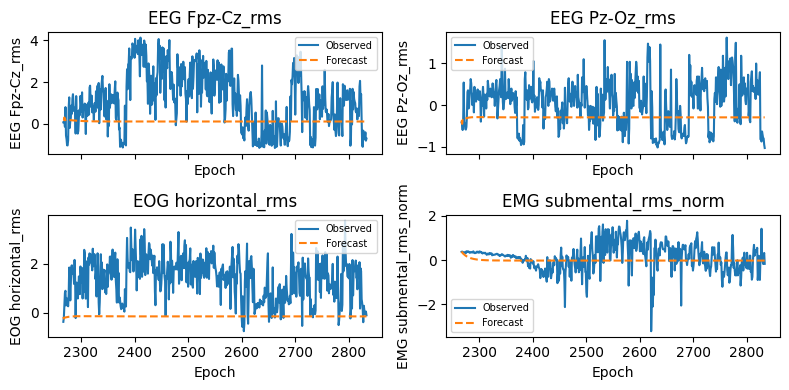

In [56]:
import matplotlib.pyplot as plt

# Explicitly select subject 465, night 2
sid = "465"
night = "2"

res_obj = forecast_results[(sid, night)]

n_signals = len(signal_cols)

# Create subplots: 2 columns layout (adjust as needed)
ncols = 2
nrows = (n_signals + ncols - 1) // ncols  # ceil division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 2*nrows), sharex=True)

# Flatten axes for easy iteration (in case nrows * ncols > n_signals)
axes = axes.flatten()

for i, col in enumerate(signal_cols):
    ax = axes[i]
    ax.plot(res_obj["actual"].index, res_obj["actual"][col], label="Observed", linewidth=1.5)
    ax.plot(res_obj["forecast"].index, res_obj["forecast"][col], label="Forecast", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(col)
    ax.legend(fontsize=7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
    

The VAR model captures general trends and baseline shifts for all signals but struggles with rapid, high-frequency variations, particularly in EEG and EOG channels. Forecast accuracy is highest for EMG, reflecting stronger short-term temporal structure, while EEG and EOG signals are more bursty and less predictable. These results support the idea that short-term physiological dynamics in sleep are partially structured but also contain stochastic components, especially in signals linked to neural or ocular events.